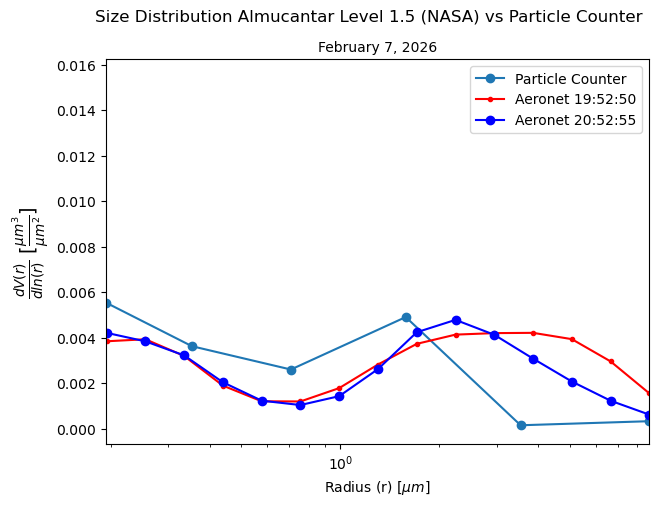

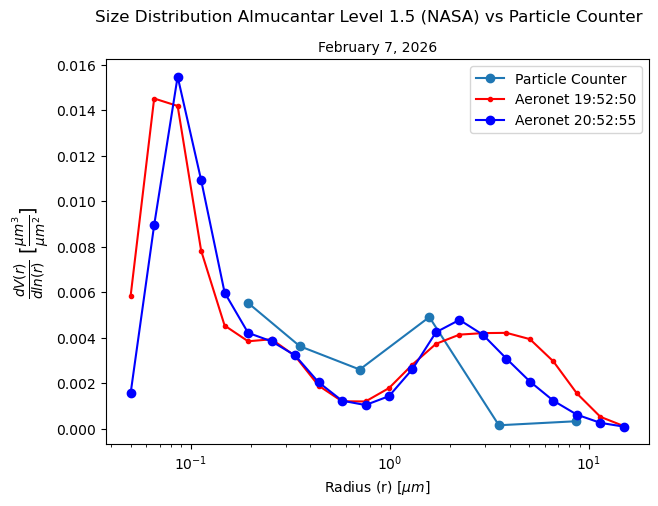

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('20260207_Rexburg_Idaho.csv')

y1 = data.iloc[0,5:27].values
y2 = data.iloc[1,5:27].values
x = data.columns[5:27].astype(float).values

csv_path = "Particle Counter Balloon.csv"

df = pd.read_csv(csv_path)
df = df.dropna(how="all").copy()

df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
df = df.dropna(subset=["Time"]).sort_values("Time").reset_index(drop=True)

count_cols_all = [
    "Count1 (dM3)",
    "Count2 (dM3)",
    "Count3 (dM3)",
    "Count4 (dM3)",
    "Count5 (dM3)",
    "Count6 (dM3)",
]

for col in count_cols_all + ["altitude"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================================
# 2. Define particle counter diameter bins
# ============================================================
# Count1: 0.3–0.5 um diameter
# Count2: 0.5–1.0 um diameter
# Count3: 1.0–2.0 um diameter
# Count4: 2.0–5.0 um diameter
# Count5: 5.0–10.0 um diameter
# Count6: 10.0–30.0 um diameter ASSUMED
#
# The upper edge for Count6 is not measured by the counter.
# We choose 30 um diameter so the radius upper edge is 15 um,
# matching the upper end of the AERONET radius range.

D_edges_um = np.array([0.3, 0.5, 1.0, 2.0, 5.0, 10.0, 30.0])

r_edges_um = D_edges_um / 2

r_mid_um = np.sqrt(r_edges_um[:-1] * r_edges_um[1:])
dlnr = np.log(r_edges_um[1:] / r_edges_um[:-1])

count_cols = [
    "Count1 (dM3)",
    "Count2 (dM3)",
    "Count3 (dM3)",
    "Count4 (dM3)",
    "Count5 (dM3)",
    "Count6 (dM3)",
]

dN_dM3 = df[count_cols].to_numpy(dtype=float)

# ============================================================
# 3. Convert count/m^3 to local dV/dln(r)
# ============================================================
# dN/dln(r) ≈ Delta N / Delta ln(r)
# dV/dln(r) = (4pi/3) r^3 dN/dln(r)
#
# r is in um, so local result has unit:
# um^3 / m^3

dVdlnr_local = (4 * np.pi / 3) * (r_mid_um**3) * (dN_dM3 / dlnr)

# Add local distributions back into dataframe
for i, r in enumerate(r_mid_um):
    df[f"dVdlnr_local_r={r:.3f}um_um3_per_m3"] = dVdlnr_local[:, i]

# ============================================================
# 4. Interpolate altitude for each particle-counter time
# ============================================================
# Your altitude column is sparse, so this fills altitude by time interpolation.
# This assumes altitude is in meters. If your altitude is in feet, set:
# ALTITUDE_UNIT = "ft"

ALTITUDE_UNIT = "m"   # change to "ft" if altitude is in feet

df = df.set_index("Time")

df["altitude_interp"] = (
    df["altitude"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

df = df.reset_index()

if ALTITUDE_UNIT.lower() == "ft":
    df["altitude_m"] = df["altitude_interp"] * 0.3048
else:
    df["altitude_m"] = df["altitude_interp"]

# ============================================================
# 5. Column-integrate to AERONET-like units
# ============================================================
# AERONET-like:
# dV/dln(r) column = integral[local dV/dln(r) dz]
#
# local dV/dln(r): um^3/m^3
# dz: m
# result: um^3/m^2
#
# Convert m^2 to um^2:
# 1 m^2 = 1e12 um^2
# so multiply by 1e-12.
#
# final unit: um^3/um^2

# Use ascent only up to maximum altitude to avoid double-counting descent
idx_max_alt = df["altitude_m"].idxmax()
profile = df.loc[:idx_max_alt].copy()

# Sort by altitude for integration
profile = profile.sort_values("altitude_m")

z_m = profile["altitude_m"].to_numpy(dtype=float)

local_cols = [f"dVdlnr_local_r={r:.3f}um_um3_per_m3" for r in r_mid_um]
local_profile = profile[local_cols].to_numpy(dtype=float)

# Column integrated AERONET-like distribution
dVdlnr_column = 1e-12 * np.trapz(local_profile, z_m, axis=0)

column_result = pd.DataFrame({
    "radius_um": r_mid_um,
    "diameter_bin_low_um": D_edges_um[:-1],
    "diameter_bin_high_um": D_edges_um[1:],
    "dlnr": dlnr,
    "dVdlnr_column_um3_per_um2": dVdlnr_column,
})

plt.figure(figsize=(7, 5))
plt.plot(column_result["radius_um"],column_result["dVdlnr_column_um3_per_um2"],marker="o",label="Particle Counter")
plt.plot(x, y1, 'r.-', label="Aeronet 19:52:50")
plt.plot(x, y2, 'bo-', label="Aeronet 20:52:55")
plt.xlim(min(column_result["radius_um"]),max(column_result["radius_um"]))
plt.xscale("log")
plt.ylabel(r'$\frac{dV(r)}{dln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]',fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle('Size Distribution Almucantar Level 1.5 (NASA) vs Particle Counter')
plt.title('February 7, 2026',fontsize=10)
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(column_result["radius_um"],column_result["dVdlnr_column_um3_per_um2"],marker="o",label="Particle Counter")
plt.plot(x, y1, 'r.-', label="Aeronet 19:52:50")
plt.plot(x, y2, 'bo-', label="Aeronet 20:52:55")
# plt.xlim(min(column_result["radius_um"]),max(column_result["radius_um"]))
plt.xscale("log")
plt.ylabel(r'$\frac{dV(r)}{dln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]',fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle('Size Distribution Almucantar Level 1.5 (NASA) vs Particle Counter')
plt.title('February 7, 2026',fontsize=10)
plt.legend()
plt.show()